In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
from pathlib import Path

FILE_PATH = Path.cwd()

# Задание 1. Оклад медсестёр

In [3]:
nursing_home_data = pd.read_csv(FILE_PATH.joinpath('Nursing Home Data', 'Nursing Home Data_data'), sep = '\s+')


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Temp\ipykernel_3296\3253521655.py:1: SyntaxWarning: invalid escape sequence '\s'
  nursing_home_data = pd.read_csv(FILE_PATH.joinpath('Nursing Home Data', 'Nursing Home Data_data'), sep = '\s+')


In [5]:
nursing_home_data.columns

Index(['BED', 'MCDAYS', 'TDAYS', 'PCREV', 'NSAL', 'FEXP', 'RURAL'], dtype='object')

In [27]:
urban_salaries = nursing_home_data[nursing_home_data['RURAL'] == 0]['NSAL']
rural_salaries = nursing_home_data[nursing_home_data['RURAL'] == 1]['NSAL']

<Axes: >

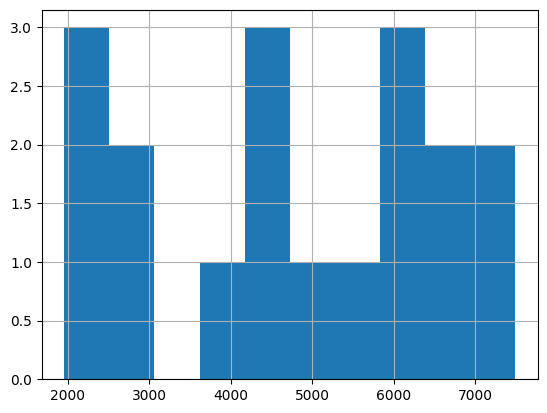

In [28]:
urban_salaries.hist()

<Axes: >

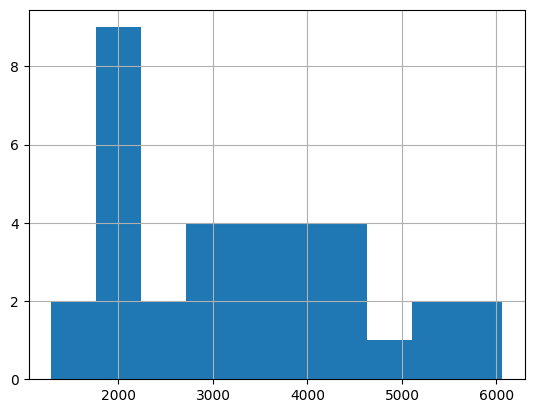

In [29]:
rural_salaries.hist()

C:\Temp\ipykernel_3296\1574588500.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='RURAL', y='NSAL', data=nursing_home_data,  palette="coolwarm")


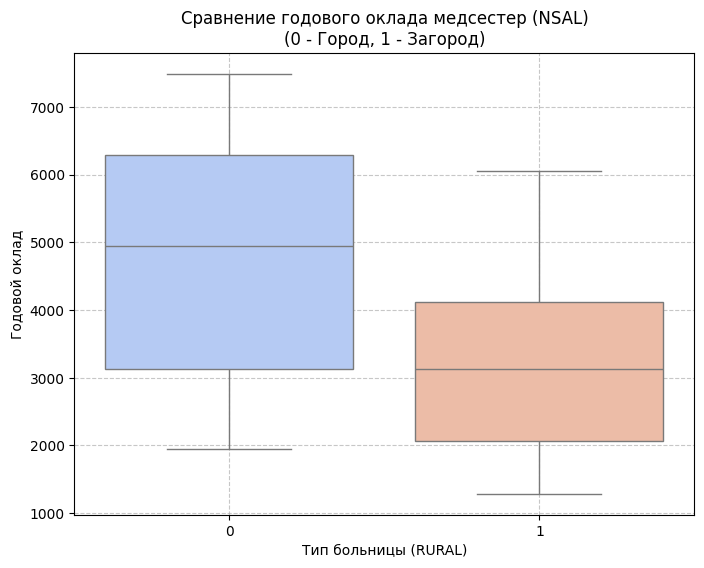

In [50]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='RURAL', y='NSAL', data=nursing_home_data,  palette="coolwarm")
plt.title('Сравнение годового оклада медсестер (NSAL)\n(0 - Город, 1 - Загород)')
plt.xlabel('Тип больницы (RURAL)')
plt.ylabel('Годовой оклад')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

На графиках видно, что медианы отличаются. Справедливо, что зарплаты в городских и загородных больницах отличаются.

### Проверка на нормальность распределения
Критерий Шапиро-Уилка (малое количество записей)

$H_0$: распределение нормальное

$H_1$: ненормальное распределение

Уровень значимости: 0.05

In [32]:
alpha = 0.05
shapiro_urban = stats.shapiro(urban_salaries)
shapiro_rural = stats.shapiro(rural_salaries)
shapiro_urban_pvalue = shapiro_urban.pvalue
shapiro_rural_pvalue = shapiro_rural.pvalue
print("Городское p-value: ", round(shapiro_urban_pvalue, 6))
print("Загородное p-value: ", round(shapiro_rural_pvalue, 6))

shapiro_urban_print = "Зарплаты в городских больницах нормально распределены" if shapiro_urban_pvalue > alpha else "Зарплаты в городских больницах не нормально распределены"
shapiro_rural_print = "Зарплаты в загородных больницах нормально распределены" if shapiro_rural_pvalue > alpha else "Зарплаты в загородных больницах не нормально распределены"

print(shapiro_urban_print)
print(shapiro_rural_print)

Городское p-value:  0.266589
Загородное p-value:  0.071782
Зарплаты в городских больницах нормально распределены
Зарплаты в загородных больницах нормально распределены


Критерий Шапиро-Уилка показал, что обе выборки взяты из нормального распределения. В качестве центра распределения возьмём среднее арифметическое.

### Проверка на равенство дисперсий

$H_0$: Vx = Vy

$H_1$: Vx != Vy

Уровень значимости: 0.05

In [35]:
alpha = 0.05
levene_pvalue = stats.levene(urban_salaries, rural_salaries).pvalue 
print("p-value: ", round(levene_pvalue, 6))
levene_test = levene_pvalue > alpha
levene_print = "Дисперсии равны" if levene_test else "Дисперсии не равны"
print(levene_print)

p-value:  0.04895
Дисперсии не равны


Дисперсии оказались не равны, значит мы не можем использовать классический t-критерий Стьюдента, так как он может дать ложный результат (ошибка первого рода). Используем t-критерий Уэлча.

### t-критерий Уэлча

$H_0$: Ex = Ey (различий в окладе в городских и негородских больницах нет)

$H_1$: Ex != Ey (различия существуют)

Уровень значимости: 0.05

In [36]:
alpha = 0.05
p_value = stats.ttest_ind(urban_salaries, rural_salaries, equal_var=False).pvalue

print('p-value: ', round(p_value, 6))
if p_value>alpha:
    print("Различий в окладе в городских и негородских больницах нет")
else:
    print("Различия в окладе в городских и негородских больницах существуют")

p-value:  0.002652
Различия в окладе в городских и негородских больницах существуют


# Задание 2. Муниципальные служащие.

In [57]:
USALL = pd.read_csv(FILE_PATH.joinpath('Unions and State Labor Law', 'Unions and State Labor Law_data'), sep = '\s+')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Temp\ipykernel_3296\933245760.py:1: SyntaxWarning: invalid escape sequence '\s'
  USALL = pd.read_csv(FILE_PATH.joinpath('Unions and State Labor Law', 'Unions and State Labor Law_data'), sep = '\s+')


In [46]:
states_no_law = USALL[USALL['COMP'] == 0]['DENS'] 
states_law = USALL[USALL['COMP'] == 1]['DENS']  

C:\Temp\ipykernel_3296\634960461.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='COMP', y='DENS', data=USALL, palette="coolwarm")


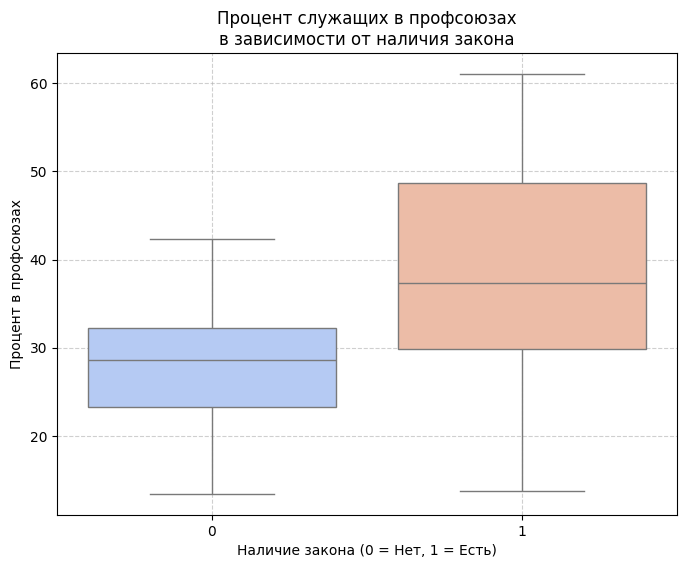

In [51]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='COMP', y='DENS', data=USALL, palette="coolwarm")
plt.title('Процент служащих в профсоюзах\nв зависимости от наличия закона')
plt.xlabel('Наличие закона (0 = Нет, 1 = Есть)')
plt.ylabel('Процент в профсоюзах')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

На графике видно, что процент муниципальных служащих в профсоюзах зависит от того, принят закон или нет. 

### Проверка на нормальность распределения
Критерий Шапиро-Уилка (малое количество записей)

$H_0$: распределение нормальное

$H_1$: ненормальное распределение

Уровень значимости: 0.05

In [56]:
alpha = 0.05
shapiro_law = stats.shapiro(urban_salaries)
shapiro_no_law = stats.shapiro(rural_salaries)
shapiro_law_pvalue = shapiro_urban.pvalue
shapiro_no_law_pvalue = shapiro_rural.pvalue
print("Закон принят p-value: ", round(shapiro_law_pvalue, 6))
print("Закон не принят p-value: ", round(shapiro_no_law_pvalue, 6))

resalt_print = "Обе выборки взяты из нормального распределения" if (shapiro_law_pvalue > alpha) and\
      (shapiro_no_law_pvalue > alpha) else "Хотя бы одна из выборок не нормально распределена"


print(resalt_print)

Закон принят p-value:  0.266589
Закон не принят p-value:  0.071782
Обе выборки взяты из нормального распределения


Критерий Шапиро-Уилка показал, что обе выборки взяты из нормального распределения. В качестве центра распределения возьмём среднее арифметическое.
### Проверка на равенство дисперсий

$H_0$: Vx = Vy

$H_1$: Vx != Vy

Уровень значимости: 0.05

In [53]:
alpha = 0.05
levene_pvalue = stats.levene(states_no_law, states_law).pvalue 
print("p-value: ", round(levene_pvalue, 6))
levene_test = levene_pvalue > alpha
levene_print = "Дисперсии равны" if levene_test else "Дисперсии не равны"
print(levene_print)

p-value:  0.00159
Дисперсии не равны


Дисперсии оказались не равны, значит мы не можем использовать классический t-критерий Стьюдента, так как он может дать ложный результат (ошибка первого рода). Используем t-критерий Уэлча.
### t-критерий Уэлча

$H_0$: Ex = Ey (процент муниципальных служащих не зависит от закона)

$H_1$: Ex != Ey (закон влияет на процент муниципальных служащих)

Уровень значимости: 0.05


In [54]:
alpha = 0.05
p_value = stats.ttest_ind(states_no_law, states_law, equal_var=False).pvalue

print('p-value: ', round(p_value, 6))
if p_value>alpha:
    print("Принимаем гипотезу H0")
    print("Процент муниципальных служащих не зависит от закона")
else:
    print("Отвергаем гипотезу H0")
    print("Закон влияет на процент муниципальных служащих")

p-value:  0.000563
Отвергаем гипотезу H0
Закон влияет на процент муниципальных служащих
